In [1]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

# COCO 자동 다운로드 + 1 epoch 테스트 학습
model = YOLO("yolo26n-seg.pt")

model.train(
    data="coco-seg.yaml",
    epochs=1,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco-seg.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7

RuntimeError: Dataset 'coco-seg.yaml' error ❌ 'coco-seg.yaml' does not exist

클래스(10개) bbox만 남김

그 결과 라벨이 비어버린 이미지는 이미지+라벨 둘 다 제거

train/val/test 모두 동일 적용

새 데이터셋(datasets/coco_pedestrian)에 필요한 이미지만 복사

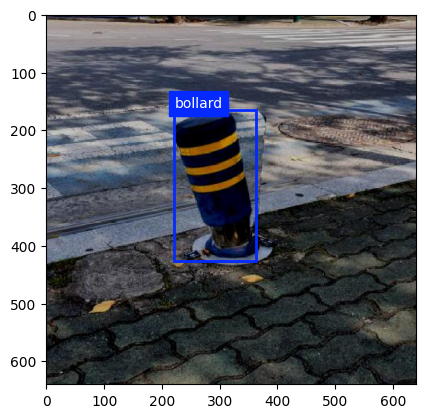

In [44]:
import matplotlib.pyplot as plt
from ultralytics.data.utils import visualize_image_annotations
import os

# 1. 파일 경로 설정
img_path = '/content/bollard-1/valid/images/10_jpg.rf.21bbefc224cd7b51631ce589aa3aaf11.jpg'
label_path = '/content/bollard-1/valid/labels/10_jpg.rf.21bbefc224cd7b51631ce589aa3aaf11.txt'

# 2. 데이터 구성 정보 수정 (KeyError 방지)
# 함수 내부에서 label_map[int(cls)] 형태로 참조하므로 딕셔너리를 직접 할당합니다.
class_names = {0: 'bollard', 1: 'class_1', 2: 'class_2'}

# 3. 시각화 수행
if os.path.exists(img_path) and os.path.exists(label_path):
    try:
        # 이 함수는 내부적으로 plt.show()를 실행할 수 있습니다.
        visualize_image_annotations(img_path, label_path, class_names)
    except Exception as e:
        print(f"시각화 중 오류 발생: {e}")
else:
    print("파일 경로를 다시 확인해주세요.")

시각화 중 (임시 라벨 사용): 000000000139.jpg


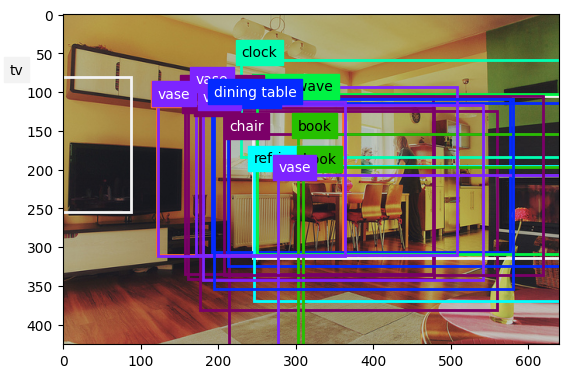

In [47]:
import os
import tempfile
from ultralytics.data.utils import visualize_image_annotations

# 1. 파일 경로 설정
img_path = '/content/datasets/coco/images/val2017/000000000139.jpg'
label_path = '/content/datasets/coco/labels/val2017/000000000139.txt'

# 2. 클래스 이름 정의
coco_names = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]
class_names = {i: name for i, name in enumerate(coco_names)}

# 3. 임시 파일을 활용한 시각화
if os.path.exists(img_path) and os.path.exists(label_path):
    # 값이 5개보다 많은 경우를 대비해 앞의 5개만 추출하여 임시 파일 생성
    with open(label_path, 'r') as f:
        lines = f.readlines()

    clean_lines = []
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            # 앞의 5개 값(cls, x, y, w, h)만 유지
            clean_lines.append(" ".join(parts[:5]))

    # 임시 텍스트 파일 생성 (ValueError 회피용)
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as tmp:
        tmp.write("\n".join(clean_lines))
        tmp_label_path = tmp.name

    try:
        print(f"시각화 중 (임시 라벨 사용): {os.path.basename(img_path)}")
        visualize_image_annotations(img_path, tmp_label_path, class_names)
    finally:
        # 시각화 후 임시 파일 삭제
        if os.path.exists(tmp_label_path):
            os.remove(tmp_label_path)
else:
    print("경로를 확인해주세요.")

In [26]:
import os
import shutil

# ===== 원본 COCO (ultralytics coco.yaml로 받은 경로) =====
SRC_ROOT = "datasets/coco"
DST_ROOT = "datasets/coco_pedestrian1"

# ===== 남길 COCO class id (원본 기준) =====
# 0 person, 1 bicycle, 2 car, 3 motorcycle, 5 bus, 7 truck, 9 traffic light, 11 stop sign, 13 bench, 16 dog
KEEP_OLD_IDS = {0, 1, 2, 3, 5, 7, 9, 11, 13, 16}

# ===== 새 클래스 이름(최종 0~9) =====
NEW_NAMES = [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "bus",
    "truck",
    "traffic light",
    "stop sign",
    "bench",
    "dog",
]

# old id -> new id (연속 인덱스)
OLD_TO_NEW = {old_id: new_id for new_id, old_id in enumerate(sorted(KEEP_OLD_IDS))}

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def filtered_label_lines(src_txt: str):
    """원본 라벨에서 KEEP 클래스만 남기고 new id로 바꾼 라인 리스트를 반환."""
    if not os.path.exists(src_txt):
        return []

    out = []
    with open(src_txt, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                old_cls = int(float(parts[0]))
            except:
                continue

            if old_cls not in KEEP_OLD_IDS:
                continue

            parts[0] = str(OLD_TO_NEW[old_cls])
            out.append(" ".join(parts))
    return out

def process_split(split: str):
    src_img_dir = os.path.join(SRC_ROOT, "images", split)
    src_lbl_dir = os.path.join(SRC_ROOT, "labels", split)

    if not os.path.exists(src_img_dir):
        print(f"⚠️ split images not found: {src_img_dir}")
        return {"split": split, "kept": 0, "dropped": 0}

    dst_img_dir = os.path.join(DST_ROOT, "images", split)
    dst_lbl_dir = os.path.join(DST_ROOT, "labels", split)
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    kept = 0
    dropped = 0

    for fname in os.listdir(src_img_dir):
        if not fname.lower().endswith(IMG_EXTS):
            continue

        stem = os.path.splitext(fname)[0]
        src_img = os.path.join(src_img_dir, fname)
        src_txt = os.path.join(src_lbl_dir, stem + ".txt")

        lines = filtered_label_lines(src_txt)

        # ✅ 핵심: 필터링 후 bbox가 1개도 없으면 이미지 자체를 버림
        if len(lines) == 0:
            dropped += 1
            continue

        # keep
        dst_img = os.path.join(dst_img_dir, fname)
        dst_txt = os.path.join(dst_lbl_dir, stem + ".txt")

        shutil.copy2(src_img, dst_img)
        with open(dst_txt, "w", encoding="utf-8") as f:
            f.write("\n".join(lines) + "\n")

        kept += 1

    return {"split": split, "kept": kept, "dropped": dropped}

def write_yaml():
    ensure_dir(DST_ROOT)
    yaml_path = os.path.join(DST_ROOT, "data.yaml")
    with open(yaml_path, "w", encoding="utf-8") as f:
        f.write(f"path: {DST_ROOT}\n\n")
        f.write("train: images/train2017\n")
        f.write("val: images/val2017\n\n")
        # test가 있으면 학습에 쓰진 않지만 참고로 남겨둘 수 있음(ultralytics는 test 키도 읽음)
        if os.path.exists(os.path.join(DST_ROOT, "images", "test2017")):
            f.write("test: images/test2017\n\n")

        f.write("names:\n")
        for i, n in enumerate(NEW_NAMES):
            f.write(f"  {i}: {n}\n")
    return yaml_path

# ===== 실행 =====
if os.path.exists(DST_ROOT):
    shutil.rmtree(DST_ROOT)

stats = []
stats.append(process_split("train2017"))
stats.append(process_split("val2017"))
# test2017이 있으면 같이 생성
if os.path.exists(os.path.join(SRC_ROOT, "images", "test2017")) and os.path.exists(os.path.join(SRC_ROOT, "labels", "test2017")):
    stats.append(process_split("test2017"))

yaml_path = write_yaml()

print("\n✅ 완료: 이미지까지 줄인 새 데이터셋 생성")
for s in stats:
    print(f"- {s['split']}: kept={s['kept']:,}, dropped={s['dropped']:,}")

print("\n새 data.yaml:", yaml_path)
print("클래스 수:", len(NEW_NAMES))
print("클래스:", list(enumerate(NEW_NAMES)))


✅ 완료: 이미지까지 줄인 새 데이터셋 생성
- train2017: kept=74,773, dropped=43,514
- val2017: kept=3,166, dropped=1,834

새 data.yaml: datasets/coco_pedestrian1/data.yaml
클래스 수: 10
클래스: [(0, 'person'), (1, 'bicycle'), (2, 'car'), (3, 'motorcycle'), (4, 'bus'), (5, 'truck'), (6, 'traffic light'), (7, 'stop sign'), (8, 'bench'), (9, 'dog')]


train 데이터셋 전체에서 클래스별 bbox(라벨) 개수를 집계합니다

In [27]:
import os
from collections import Counter

# ===== 경로 설정 =====
LABEL_DIR = "datasets/coco_pedestrian1/labels/train2017"

# ===== 클래스별 bbox 개수 집계 =====
class_counter = Counter()
image_counter = 0
total_boxes = 0

for fname in os.listdir(LABEL_DIR):
    if not fname.endswith(".txt"):
        continue

    image_counter += 1
    path = os.path.join(LABEL_DIR, fname)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(float(parts[0]))
        class_counter[cls_id] += 1
        total_boxes += 1

# ===== 결과 출력 =====
print(f"\n총 이미지 수: {image_counter}")
print(f"총 bbox 수: {total_boxes}\n")

print("클래스별 bbox 개수:")
for cls_id in sorted(class_counter.keys()):
    print(f"class {cls_id}: {class_counter[cls_id]}")


총 이미지 수: 74773
총 bbox 수: 362669

클래스별 bbox 개수:
class 0: 257252
class 1: 7056
class 2: 43531
class 3: 8654
class 4: 6061
class 5: 9970
class 6: 12842
class 7: 1983
class 8: 9820
class 9: 5500


class 0만 존재하는 이미지 개수를 세기

In [28]:
import os

LABEL_DIR = "datasets/coco_pedestrian1/labels/train2017"

only_class0_image_count = 0
only_class0_bbox_count = 0

for fname in os.listdir(LABEL_DIR):
    if not fname.endswith(".txt"):
        continue

    path = os.path.join(LABEL_DIR, fname)

    with open(path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    if not lines:
        continue

    classes_in_image = []
    class0_count_in_image = 0

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(float(parts[0]))
        classes_in_image.append(cls_id)

        if cls_id == 0:
            class0_count_in_image += 1

    # 이미지에 등장한 클래스 종류
    unique_classes = set(classes_in_image)

    # 오직 class 0만 존재하는 경우
    if unique_classes == {0}:
        only_class0_image_count += 1
        only_class0_bbox_count += class0_count_in_image


print("class 0만 있는 이미지 수:", only_class0_image_count)
print("그 이미지들 안의 class 0 bbox 총 개수:", only_class0_bbox_count)

class 0만 있는 이미지 수: 45354
그 이미지들 안의 class 0 bbox 총 개수: 162804


class 0만 있는 이미지를 다지워

In [29]:
import os
from glob import glob

LABEL_DIR = "datasets/coco_pedestrian1/labels/train2017"
IMAGE_DIR = "datasets/coco_pedestrian1/images/train2017"

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def is_person_only_label(txt_path: str) -> bool:
    """라벨 파일에 등장하는 클래스가 오직 {0}인지 판정."""
    classes = set()
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            classes.add(cls_id)
            if cls_id != 0:
                return False
    return classes == {0}

def find_image_path(stem: str):
    """stem(확장자 없는 파일명)으로 실제 이미지 파일을 찾음."""
    for ext in IMG_EXTS:
        p = os.path.join(IMAGE_DIR, stem + ext)
        if os.path.exists(p):
            return p
    # 확장자가 다른 경우 대비
    hits = glob(os.path.join(IMAGE_DIR, stem + ".*"))
    for h in hits:
        if os.path.splitext(h)[1].lower() in IMG_EXTS:
            return h
    return None

deleted_images = 0
deleted_labels = 0
missing_images = 0

for fname in os.listdir(LABEL_DIR):
    if not fname.endswith(".txt"):
        continue

    txt_path = os.path.join(LABEL_DIR, fname)

    if not is_person_only_label(txt_path):
        continue

    stem = os.path.splitext(fname)[0]
    img_path = find_image_path(stem)

    # 1) 라벨 삭제
    os.remove(txt_path)
    deleted_labels += 1

    # 2) 이미지 삭제
    if img_path is not None:
        os.remove(img_path)
        deleted_images += 1
    else:
        missing_images += 1

print("✅ 삭제 완료")
print("삭제된 라벨 수:", deleted_labels)
print("삭제된 이미지 수:", deleted_images)
print("라벨은 있었지만 이미지 못 찾은 경우:", missing_images)

✅ 삭제 완료
삭제된 라벨 수: 45354
삭제된 이미지 수: 45354
라벨은 있었지만 이미지 못 찾은 경우: 0


In [38]:
import cv2
import matplotlib.pyplot as plt
import os

# 경로 및 클래스 설정
img_dir = '/content/datasets/coco_pedestrian1/images/val2017'
label_dir = '/content/datasets/coco_pedestrian1/labels/val2017'
class_names = {
    0: "person", 1: "bicycle", 2: "car", 3: "motorcycle", 4: "bus",
    5: "truck", 6: "traffic light", 7: "stop sign", 8: "bench", 9: "dog"
}

img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')][:10]

def draw_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = list(map(float, line.split()))
                if len(parts) < 5:
                    continue

                # 앞의 5개 값(class, x_c, y_c, w, h)만 추출
                cls, x_c, y_c, bw, bh = parts[:5]

                x1 = int((x_c - bw/2) * w)
                y1 = int((y_c - bh/2) * h)
                x2 = int((x_c + bw/2) * w)
                y2 = int((y_c + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                label_text = class_names.get(int(cls), f"Class {int(cls)}")
                cv2.putText(img, label_text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img

# 시각화 실행
plt.figure(figsize=(20, 10))
for i, img_file in enumerate(img_files):
    img_path = os.path.join(img_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt'))

    result_img = draw_boxes(img_path, label_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(result_img)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

ROBOFLOW 에서 BOLLARD 데이터셋 준비

In [12]:
from roboflow import Roboflow
rf = Roboflow(api_key="4ldbiJwQ0uNDJ8oNJhEs")
project = rf.workspace("test-w9qag").project("bollard-v2gn5-t7lrj-ycf6t")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...


✅ class 1 전부 제거 + 빈 이미지까지 삭제 (재귀 탐색 버전)

In [16]:
import os
from pathlib import Path
from collections import Counter

DATA_ROOT = Path("/content/bollard-1")
REMOVE_CLASS_ID = 1
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def find_image_for_stem(images_dir: Path, stem: str):
    for ext in IMG_EXTS:
        p = images_dir / f"{stem}{ext}"
        if p.exists():
            return p
    # 혹시 확장자 대소문자/기타인 경우 대비
    for p in images_dir.glob(stem + ".*"):
        if p.suffix.lower() in IMG_EXTS:
            return p
    return None

def count_bboxes():
    cnt = Counter()
    label_files = 0
    for lbl_dir in DATA_ROOT.rglob("labels"):
        if not lbl_dir.is_dir():
            continue
        for txt in lbl_dir.glob("*.txt"):
            label_files += 1
            with open(txt, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) < 5:
                        continue
                    cls = int(float(parts[0]))
                    cnt[cls] += 1
    return label_files, cnt

# --- 삭제 전 집계 ---
files_before, cnt_before = count_bboxes()
print("=== BEFORE ===")
print("label files:", files_before)
for k in sorted(cnt_before):
    print(f"class {k}: {cnt_before[k]}")

removed_boxes = 0
deleted_label_files = 0
deleted_images = 0
rewritten_label_files = 0

# labels 폴더를 재귀 탐색
for labels_dir in DATA_ROOT.rglob("labels"):
    if not labels_dir.is_dir():
        continue

    # 일반적으로 같은 레벨에 images 폴더가 있음: .../train/labels -> .../train/images
    images_dir = labels_dir.parent / "images"

    for txt_path in labels_dir.glob("*.txt"):
        stem = txt_path.stem

        with open(txt_path, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f if ln.strip()]

        if not lines:
            continue

        new_lines = []
        removed_in_file = 0

        for ln in lines:
            parts = ln.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            if cls == REMOVE_CLASS_ID:
                removed_in_file += 1
            else:
                new_lines.append(ln)

        if removed_in_file == 0:
            continue

        removed_boxes += removed_in_file

        # 라벨이 비었으면: 라벨 파일 삭제 + 이미지 삭제
        if len(new_lines) == 0:
            try:
                txt_path.unlink()
                deleted_label_files += 1
            except FileNotFoundError:
                pass

            if images_dir.exists():
                img_path = find_image_for_stem(images_dir, stem)
                if img_path and img_path.exists():
                    img_path.unlink()
                    deleted_images += 1
        else:
            with open(txt_path, "w", encoding="utf-8") as f:
                f.write("\n".join(new_lines) + "\n")
            rewritten_label_files += 1

print("\n✅ DONE (remove class 1)")
print("removed bbox lines (class 1):", removed_boxes)
print("rewritten label files:", rewritten_label_files)
print("deleted label files (became empty):", deleted_label_files)
print("deleted images (matching empty labels):", deleted_images)

# --- 삭제 후 집계 ---
files_after, cnt_after = count_bboxes()
print("\n=== AFTER ===")
print("label files:", files_after)
for k in sorted(cnt_after):
    print(f"class {k}: {cnt_after[k]}")

=== BEFORE ===
label files: 1692
class 0: 3377
class 1: 207

✅ DONE (remove class 1)
removed bbox lines (class 1): 207
rewritten label files: 0
deleted label files (became empty): 47
deleted images (matching empty labels): 47

=== AFTER ===
label files: 1645
class 0: 3377


✅ Roboflow bollard → coco_pedestrian 병합(라벨 0→11 변경) 코드

In [30]:
import os
import shutil
from pathlib import Path

ROBO_ROOT = Path("/content/bollard-1")
DEST_ROOT = Path("/content/datasets/coco_pedestrian1")

SPLIT_MAP = {"train": "train2017", "valid": "val2017", "test": "test2017"}
CLASS_MAP = {0: 11}  # bollard -> 11

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
PREFIX = "rf_bollard_"

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def find_image(images_dir: Path, stem: str):
    for ext in IMG_EXTS:
        p = images_dir / f"{stem}{ext}"
        if p.exists():
            return p
    for p in images_dir.glob(stem + ".*"):
        if p.suffix.lower() in IMG_EXTS:
            return p
    return None

def unique_stem(dst_dir: Path, base_stem: str, img_suffix: str):
    """dst_dir에 같은 stem이 있으면 rf_xxx_1, rf_xxx_2 ...로 고유화."""
    stem = base_stem
    k = 1
    while (dst_dir / f"{stem}{img_suffix}").exists() or (dst_dir.parent.parent / "labels" / dst_dir.name / f"{stem}.txt").exists():
        stem = f"{base_stem}_{k}"
        k += 1
    return stem

def remap_label(src_txt: Path):
    out = []
    with open(src_txt, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            old_id = int(float(parts[0]))
            if old_id not in CLASS_MAP:
                continue
            parts[0] = str(CLASS_MAP[old_id])
            out.append(" ".join(parts))
    return out

def merge_split(robo_split: str, dest_split: str):
    src_img_dir = ROBO_ROOT / robo_split / "images"
    src_lbl_dir = ROBO_ROOT / robo_split / "labels"

    if not src_img_dir.exists() or not src_lbl_dir.exists():
        print(f"⏭️  스킵: {robo_split} (images/labels 폴더 없음)")
        return 0, 0, 0

    dst_img_dir = DEST_ROOT / "images" / dest_split
    dst_lbl_dir = DEST_ROOT / "labels" / dest_split
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    copied = 0
    skipped_no_image = 0
    skipped_empty_after_map = 0

    for src_txt in src_lbl_dir.glob("*.txt"):
        stem = src_txt.stem
        src_img = find_image(src_img_dir, stem)
        if src_img is None:
            skipped_no_image += 1
            continue

        lines = remap_label(src_txt)
        if not lines:
            skipped_empty_after_map += 1
            continue

        # 고유 파일명 생성
        base_stem = PREFIX + stem
        new_stem = unique_stem(dst_img_dir, base_stem, src_img.suffix.lower())

        dst_img = dst_img_dir / f"{new_stem}{src_img.suffix.lower()}"
        dst_txt = dst_lbl_dir / f"{new_stem}.txt"

        # 덮어쓰기 방지(혹시라도)
        if dst_img.exists() or dst_txt.exists():
            # 이론상 unique_stem에서 걸러지지만 안전망
            continue

        with open(dst_txt, "w", encoding="utf-8") as f:
            f.write("\n".join(lines) + "\n")

        shutil.copy2(src_img, dst_img)
        copied += 1

    return copied, skipped_no_image, skipped_empty_after_map

total = 0
for robo_split, dest_split in SPLIT_MAP.items():
    c, s1, s2 = merge_split(robo_split, dest_split)
    total += c
    print(f"✅ {robo_split} -> {dest_split}: copied={c}, no_image={s1}, empty_after_map={s2}")

print("\n🎉 bollard 병합 완료. 총 추가된 이미지 수:", total)

✅ train -> train2017: copied=1563, no_image=0, empty_after_map=5
✅ valid -> val2017: copied=77, no_image=0, empty_after_map=0
✅ test -> test2017: copied=0, no_image=0, empty_after_map=0

🎉 bollard 병합 완료. 총 추가된 이미지 수: 1640


✅ 병합이 제대로 됐는지 빠르게 검증

In [31]:
import os
from pathlib import Path
from collections import Counter
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import yaml

ROOT = Path("/content/datasets/coco_pedestrian1")

# 1) 라벨/이미지 경로 자동 결정(기본값)
LBL_DIR = ROOT / "labels" / "val2017"
IMG_DIR = ROOT / "images" / "val2017"
YAML_PATH = ROOT / "data.yaml"

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def count_txt_files(p: Path):
    if not p.exists():
        return 0
    return len(list(p.glob("*.txt")))

print("=== PATH CHECK ===")
print("ROOT:", ROOT)
print("LBL_DIR exists:", LBL_DIR.exists(), "| txt files:", count_txt_files(LBL_DIR))
print("IMG_DIR exists:", IMG_DIR.exists(), "| images:", (len(list(IMG_DIR.glob('*.jpg'))) if IMG_DIR.exists() else 0))
print("data.yaml exists:", YAML_PATH.exists())
print()

# 2) data.yaml에서 names 읽기
names = {}
if YAML_PATH.exists():
    with open(YAML_PATH, "r", encoding="utf-8") as f:
        y = yaml.safe_load(f)
    if isinstance(y.get("names"), list):
        names = {i: n for i, n in enumerate(y["names"])}
    elif isinstance(y.get("names"), dict):
        names = {int(k): v for k, v in y["names"].items()}

if not names:
    print("⚠️ data.yaml에서 names를 읽지 못했습니다. (names가 없거나 형식이 다름)")
    print("먼저 data.yaml을 확인해주세요.")
    raise SystemExit

target_classes = sorted(names.keys())
print("classes in data.yaml:", [(c, names[c]) for c in target_classes])
print()

# 3) 라벨 파싱/이미지 찾기
def find_image(stem: str):
    for ext in IMG_EXTS:
        p = IMG_DIR / f"{stem}{ext}"
        if p.exists():
            return p
    for p in IMG_DIR.glob(stem + ".*"):
        if p.suffix.lower() in IMG_EXTS:
            return p
    return None

def parse_label(txt_path: Path):
    boxes = []
    classes = set()
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            classes.add(cls)
            boxes.append((cls, xc, yc, w, h))
    return classes, boxes

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = (xc - w/2) * W
    y1 = (yc - h/2) * H
    x2 = (xc + w/2) * W
    y2 = (yc + h/2) * H
    return x1, y1, x2, y2

# 4) 클래스별 예시 찾기
example = {}  # cls -> (img_path, txt_path, boxes)
files = list(LBL_DIR.glob("*.txt"))

if len(files) == 0:
    print("❌ val2017 라벨 txt가 0개입니다.")
    print("val 라벨이 다른 폴더에 있거나, 아직 병합/복사가 안 된 상태일 수 있습니다.")
    raise SystemExit

for txt in files:
    classes, boxes = parse_label(txt)
    if not boxes:
        continue
    img = find_image(txt.stem)
    if img is None:
        continue
    for c in classes:
        if c in names and c not in example:
            example[c] = (img, txt, boxes)
    if len(example) == len(target_classes):
        break

missing = [c for c in target_classes if c not in example]
print(f"Found examples: {len(example)}/{len(target_classes)}")
if missing:
    print("⚠️ val2017에서 예시를 못 찾은 클래스:", [(c, names[c]) for c in missing])
print()

# 5) 시각화
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 18)
except:
    font = ImageFont.load_default()

for c in target_classes:
    if c not in example:
        continue

    img_path, txt_path, boxes = example[c]

    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    draw = ImageDraw.Draw(img)

    for cls, xc, yc, w, h in boxes:
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)
        label = f"{cls}:{names.get(cls, str(cls))}"

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)

        tb = draw.textbbox((0, 0), label, font=font)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]
        pad = 3
        tx, ty = x1, max(0, y1 - (th + 2 * pad))
        draw.rectangle([tx, ty, tx + tw + 2 * pad, ty + th + 2 * pad], fill="white")
        draw.text((tx + pad, ty + pad), label, font=font, fill="black")

    title = f"val2017 example for class {c} ({names[c]}) | {img_path.name}"
    print(title)
    print(" image:", img_path)
    print(" label:", txt_path)
    print()

    plt.figure(figsize=(9, 9))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

label file: 000000344909.txt
image file: 000000344909.jpg size: (480, 640)
x range: (0.797833, 0.888312)
y range: (0.344094, 0.367937)
w range: (0.794354, 0.891375)
h range: (0.337812, 0.369422)
first 5 rows: [(2, 0.888312, 0.344094, 0.891375, 0.337812), (2, 0.88375, 0.367937, 0.836313, 0.369422), (2, 0.797833, 0.366312, 0.794354, 0.349703)]


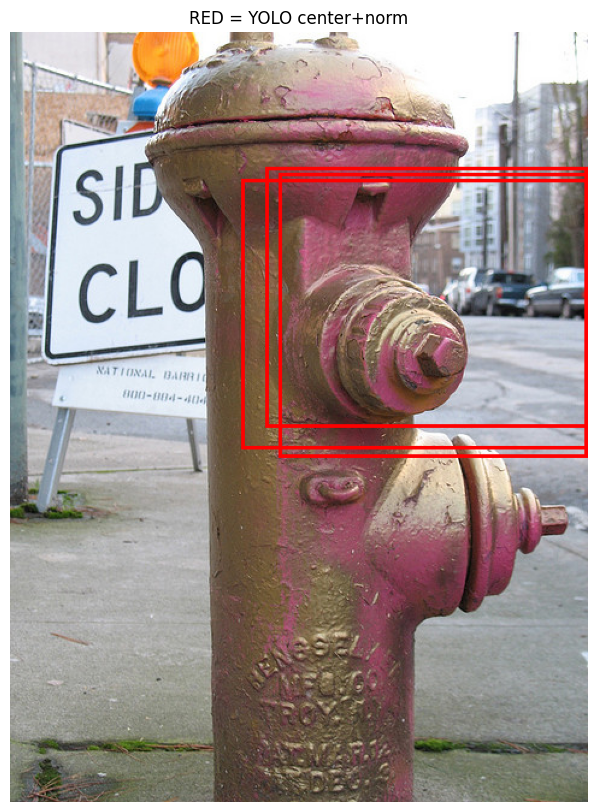

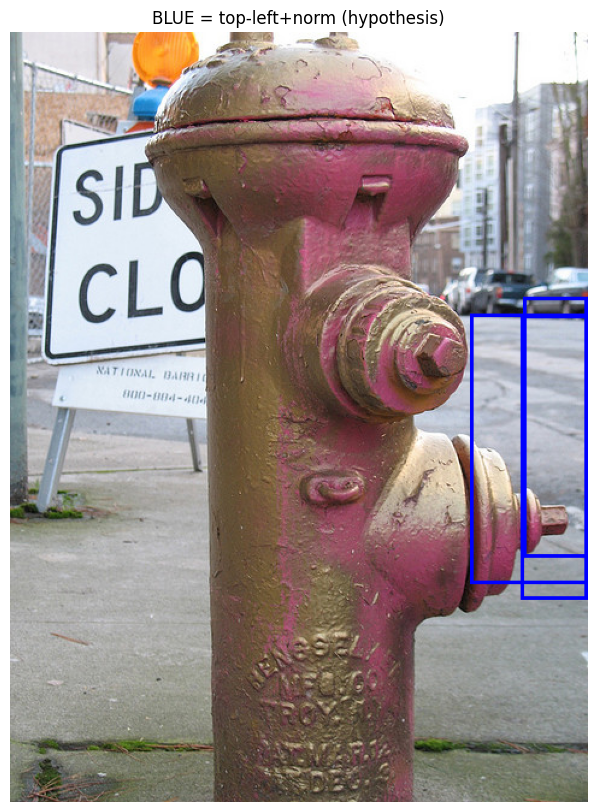

In [32]:
import os
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

ROOT = Path("/content/datasets/coco_pedestrian1")
IMG_DIR = ROOT / "images" / "val2017"
LBL_DIR = ROOT / "labels" / "val2017"
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def find_image(stem: str):
    for ext in IMG_EXTS:
        p = IMG_DIR / f"{stem}{ext}"
        if p.exists():
            return p
    for p in IMG_DIR.glob(stem + ".*"):
        if p.suffix.lower() in IMG_EXTS:
            return p
    return None

def parse(txt_path: Path):
    rows = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            parts=line.split()
            if len(parts)<5:
                continue
            cls=int(float(parts[0]))
            x,y,w,h = map(float, parts[1:5])
            rows.append((cls,x,y,w,h))
    return rows

def xyxy_center_norm(x,y,w,h,W,H):
    # YOLO: center + normalized
    x1=(x-w/2)*W; y1=(y-h/2)*H
    x2=(x+w/2)*W; y2=(y+h/2)*H
    return x1,y1,x2,y2

def xyxy_topleft_norm(x,y,w,h,W,H):
    # (가정) top-left + normalized
    x1=x*W; y1=y*H
    x2=(x+w)*W; y2=(y+h)*H
    return x1,y1,x2,y2

def clamp_box(x1,y1,x2,y2,W,H):
    x1=max(0,min(W-1,x1)); y1=max(0,min(H-1,y1))
    x2=max(0,min(W-1,x2)); y2=max(0,min(H-1,y2))
    return x1,y1,x2,y2

# 1) "이상하게 큰 박스"가 나올 법한 파일 자동 탐색: w/h가 큰 것부터
candidates = []
for txt in LBL_DIR.glob("*.txt"):
    rows = parse(txt)
    if not rows:
        continue
    # w나 h가 0.8 이상이면 일단 의심(너무 큰 박스일 가능성)
    if any((r[3] > 0.8 or r[4] > 0.8) for r in rows):
        candidates.append(txt)

# 후보가 없으면 그냥 아무 라벨 1개
txt_path = candidates[0] if candidates else next(LBL_DIR.glob("*.txt"), None)
if txt_path is None:
    raise RuntimeError("val2017 라벨 txt를 찾지 못했습니다.")

img_path = find_image(txt_path.stem)
if img_path is None:
    raise RuntimeError(f"이미지를 찾지 못했습니다: {txt_path.stem}")

rows = parse(txt_path)
img = Image.open(img_path).convert("RGB")
W,H = img.size

xs = [r[1] for r in rows]; ys = [r[2] for r in rows]; ws = [r[3] for r in rows]; hs = [r[4] for r in rows]
print("label file:", txt_path.name)
print("image file:", img_path.name, "size:", (W,H))
print("x range:", (min(xs), max(xs)))
print("y range:", (min(ys), max(ys)))
print("w range:", (min(ws), max(ws)))
print("h range:", (min(hs), max(hs)))
print("first 5 rows:", rows[:5])

# 2) 두 방식으로 각각 그려서 비교
img_center = img.copy()
img_topleft = img.copy()
d1 = ImageDraw.Draw(img_center)
d2 = ImageDraw.Draw(img_topleft)

for cls,x,y,w,h in rows:
    # center 방식
    x1,y1,x2,y2 = xyxy_center_norm(x,y,w,h,W,H)
    x1c,y1c,x2c,y2c = clamp_box(x1,y1,x2,y2,W,H)
    d1.rectangle([x1c,y1c,x2c,y2c], outline="red", width=3)

    # top-left 방식
    a1,b1,a2,b2 = xyxy_topleft_norm(x,y,w,h,W,H)
    a1c,b1c,a2c,b2c = clamp_box(a1,b1,a2,b2,W,H)
    d2.rectangle([a1c,b1c,a2c,b2c], outline="blue", width=3)

plt.figure(figsize=(10,10))
plt.imshow(img_center); plt.title("RED = YOLO center+norm"); plt.axis("off"); plt.show()

plt.figure(figsize=(10,10))
plt.imshow(img_topleft); plt.title("BLUE = top-left+norm (hypothesis)"); plt.axis("off"); plt.show()

In [36]:
from pathlib import Path
from collections import Counter
import math

ROOT = Path("/content/datasets/coco")
LBL_DIR = ROOT / "labels" / "val2017"

stats = Counter()

def is_num(x):
    return not (math.isnan(x) or math.isinf(x))

for txt in LBL_DIR.glob("*.txt"):
    with open(txt, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                stats["bad_line_len"] += 1
                continue
            try:
                cls = int(float(parts[0]))
                a,b,c,d = map(float, parts[1:5])
            except:
                stats["bad_parse"] += 1
                continue

            if not all(is_num(v) for v in [a,b,c,d]):
                stats["nan_inf"] += 1
                continue

            # YOLO(center) 정상 조건(대략)
            yolo_ok = (0 <= a <= 1 and 0 <= b <= 1 and 0 < c <= 1 and 0 < d <= 1)

            if yolo_ok:
                stats["yolo_ok"] += 1
            else:
                stats["yolo_bad"] += 1

            # xyxy처럼 보이는 패턴(정규화라고 가정): x2>x1, y2>y1이고 값들이 0~1 근처
            if 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1 and 0 <= d <= 1 and (c > a) and (d > b):
                stats["looks_xyxy_norm"] += 1

            # top-left + wh처럼 보이는 패턴: (a+c)<=1, (b+d)<=1
            if 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1 and 0 <= d <= 1 and (a + c <= 1) and (b + d <= 1):
                stats["looks_topleft_wh_norm"] += 1

print("=== label sanity ===")
for k,v in stats.most_common():
    print(f"{k}: {v}")

=== label sanity ===
yolo_ok: 36192
looks_topleft_wh_norm: 8998
looks_xyxy_norm: 7276
yolo_bad: 143


In [18]:
import os
from collections import Counter

LABEL_DIR = "/content/datasets/coco_pedestrian/labels/train2017"
cnt = Counter()

for fn in os.listdir(LABEL_DIR):
    if not fn.endswith(".txt"):
        continue
    with open(os.path.join(LABEL_DIR, fn), "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cls = int(float(line.split()[0]))
            cnt[cls] += 1

print("train2017 클래스별 bbox 수(일부):")
for k in sorted(cnt):
    if k in [0, 11]:  # person, bollard
        print(f"class {k}: {cnt[k]}")

train2017 클래스별 bbox 수(일부):
class 0: 94448
class 11: 3300


Banner 데이터셋 다운로드
roboflow

In [19]:
from roboflow import Roboflow
rf = Roboflow(api_key="4ldbiJwQ0uNDJ8oNJhEs")
project = rf.workspace("test-w9qag").project("jan26_xbanner-nwsrb")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Jan26_XBanner-1 in yolo26:: 100%|██████████| 2336/2336 [00:00<00:00, 7612.98it/s]


XBanner(Roboflow) → coco_pedestrian 병합 코드 (0→10)

In [25]:
import os
import shutil
from pathlib import Path

# ===== 경로 설정 =====
ROBO_ROOT = Path("/content/Jan26_XBanner-1")          # Roboflow banner 데이터셋
DEST_ROOT = Path("/content/datasets/coco_pedestrian/images") # 합칠 대상 데이터셋

# Roboflow split -> coco_pedestrian split 매핑
SPLIT_MAP = {
    "train": "train2017",
    "valid": "val2017",
    "test":  "test2017",   # test 없으면 자동 스킵
}

# Roboflow class id -> coco_pedestrian class id
# (당신의 coco_pedestrian YAML에서 banner = 10)
CLASS_MAP = {0: 10}

IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
PREFIX = "rf_banner_"  # 파일명 충돌 방지 prefix

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def find_image(images_dir: Path, stem: str):
    for ext in IMG_EXTS:
        p = images_dir / f"{stem}{ext}"
        if p.exists():
            return p
    for p in images_dir.glob(stem + ".*"):
        if p.suffix.lower() in IMG_EXTS:
            return p
    return None

def remap_label(src_txt: Path, dst_txt: Path) -> bool:
    """라벨을 읽어 CLASS_MAP에 맞춰 class id를 변환해 저장. 변환 후 bbox가 0개면 False."""
    if not src_txt.exists():
        return False

    out = []
    with open(src_txt, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            old_id = int(float(parts[0]))
            if old_id not in CLASS_MAP:
                continue
            parts[0] = str(CLASS_MAP[old_id])  # 0 -> 10
            out.append(" ".join(parts))

    if not out:
        return False

    with open(dst_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(out) + "\n")
    return True

def merge_split(robo_split: str, dest_split: str):
    src_img_dir = ROBO_ROOT / robo_split / "images"
    src_lbl_dir = ROBO_ROOT / robo_split / "labels"

    if not src_img_dir.exists() or not src_lbl_dir.exists():
        print(f"⏭️  스킵: {robo_split} (images/labels 폴더 없음)")
        return 0, 0, 0

    dst_img_dir = DEST_ROOT / "images" / dest_split
    dst_lbl_dir = DEST_ROOT / "labels" / dest_split
    ensure_dir(dst_img_dir)
    ensure_dir(dst_lbl_dir)

    copied = 0
    skipped_no_image = 0
    skipped_empty_after_map = 0

    for txt_path in src_lbl_dir.glob("*.txt"):
        stem = txt_path.stem
        img_path = find_image(src_img_dir, stem)
        if img_path is None:
            skipped_no_image += 1
            continue

        new_stem = PREFIX + stem
        dst_img_path = dst_img_dir / (new_stem + img_path.suffix.lower())
        dst_txt_path = dst_lbl_dir / (new_stem + ".txt")

        ok = remap_label(txt_path, dst_txt_path)
        if not ok:
            skipped_empty_after_map += 1
            if dst_txt_path.exists():
                dst_txt_path.unlink()
            continue

        shutil.copy2(img_path, dst_img_path)
        copied += 1

    return copied, skipped_no_image, skipped_empty_after_map

total = 0
for robo_split, dest_split in SPLIT_MAP.items():
    c, s1, s2 = merge_split(robo_split, dest_split)
    total += c
    print(f"✅ {robo_split} -> {dest_split}: copied={c}, no_image={s1}, empty_after_map={s2}")

print("\n🎉 병합 완료. 총 추가된 이미지 수:", total)

✅ train -> train2017: copied=1012, no_image=0, empty_after_map=0
✅ valid -> val2017: copied=100, no_image=0, empty_after_map=0
✅ test -> test2017: copied=50, no_image=0, empty_after_map=0

🎉 병합 완료. 총 추가된 이미지 수: 1162


병합 확인 코드 (train/val에서 class 10이 들어갔는지)

In [24]:
import os
from collections import Counter

def count_cls(label_dir, target_cls):
    total = 0
    for fn in os.listdir(label_dir):
        if not fn.endswith(".txt"):
            continue
        with open(os.path.join(label_dir, fn), "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                cls = int(float(line.split()[0]))
                if cls == target_cls:
                    total += 1
    return total

train_dir = "/content/datasets/coco_pedestrian/labels/train2017"
val_dir   = "/content/datasets/coco_pedestrian/labels/val2017"

print("train2017 class 10 (banner) boxes:", count_cls(train_dir, 10))
print("val2017   class 10 (banner) boxes:", count_cls(val_dir, 10))

train2017 class 10 (banner) boxes: 2104
val2017   class 10 (banner) boxes: 185


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
model.train(
    data="datasets/coco_pedestrian/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)